In [23]:
import sys
print(sys.executable)



/Users/ruben/Desktop/multi-agent-portfolio-manager/.venv/bin/python


In [24]:
import os
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands
from langchain_groq import ChatGroq

# Colle ta clé Groq ici
GROQ_API_KEY = "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" 

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
    temperature=0.3
)

print("✅ Configuration OK — LLM: LLaMA 3 70B via Groq")


✅ Configuration OK — LLM: LLaMA 3 70B via Groq


In [25]:
# Univers d'actifs
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "GS", "SPY", "TLT", "GLD", "XOM"]

# Téléchargement des données (1 an)
print("📥 Téléchargement des données...")
data = yf.download(TICKERS, period="1y", auto_adjust=True)["Close"]
data = data.dropna()

returns = data.pct_change().dropna()

print(f"✅ Données récupérées : {data.shape[0]} jours, {data.shape[1]} actifs")
print(data.tail(3))


[**********            20%                       ]  2 of 10 completed

📥 Téléchargement des données...


[*********************100%***********************]  10 of 10 completed

✅ Données récupérées : 252 jours, 10 actifs
Ticker            AAPL        AMZN         GLD       GOOGL          GS  \
Date                                                                     
2026-05-05  284.179993  273.549988  418.269989  388.429993  918.890015   
2026-05-06  287.510010  274.989990  430.959991  398.040009  937.349976   
2026-05-07  288.834991  272.075012  431.519989  395.950012  925.289978   

Ticker             JPM        MSFT         SPY        TLT         XOM  
Date                                                                   
2026-05-05  309.399994  411.380005  723.770020  85.430000  154.880005  
2026-05-06  314.899994  413.959991  733.830017  86.080002  148.690002  
2026-05-07  307.660004  421.570007  731.369995  85.724998  146.539993  


In [26]:
def analyze_technical(ticker):
    prices = data[ticker]
    
    rsi = RSIIndicator(close=prices, window=14).rsi().iloc[-1]
    macd_ind = MACD(close=prices)
    macd_val = macd_ind.macd().iloc[-1]
    macd_sig = macd_ind.macd_signal().iloc[-1]
    bb = BollingerBands(close=prices, window=20)
    bb_high = bb.bollinger_hband().iloc[-1]
    bb_low = bb.bollinger_lband().iloc[-1]
    current_price = prices.iloc[-1]
    bb_position = (current_price - bb_low) / (bb_high - bb_low)
    perf_1m = (prices.iloc[-1] / prices.iloc[-21] - 1) * 100
    perf_3m = (prices.iloc[-1] / prices.iloc[-63] - 1) * 100

    return {
        "ticker": ticker,
        "rsi": round(rsi, 2),
        "macd_bullish": macd_val > macd_sig,
        "bb_position": round(bb_position, 2),
        "perf_1m": round(perf_1m, 2),
        "perf_3m": round(perf_3m, 2)
    }

print("📈 Analyse technique en cours...")
technical_signals = {t: analyze_technical(t) for t in TICKERS}

for t, s in technical_signals.items():
    signal = "🟢 BULLISH" if s["macd_bullish"] and s["rsi"] < 70 else "🔴 BEARISH"
    print(f"{t}: RSI={s['rsi']} | MACD={'↑' if s['macd_bullish'] else '↓'} | Perf 1M={s['perf_1m']}% | {signal}")


📈 Analyse technique en cours...
AAPL: RSI=70.25 | MACD=↑ | Perf 1M=10.88% | 🔴 BEARISH
MSFT: RSI=58.22 | MACD=↓ | Perf 1M=13.0% | 🔴 BEARISH
GOOGL: RSI=81.29 | MACD=↑ | Perf 1M=24.32% | 🔴 BEARISH
AMZN: RSI=75.76 | MACD=↑ | Perf 1M=16.45% | 🔴 BEARISH
JPM: RSI=50.46 | MACD=↓ | Perf 1M=-0.86% | 🔴 BEARISH
GS: RSI=55.6 | MACD=↓ | Perf 1M=2.39% | 🔴 BEARISH
SPY: RSI=72.84 | MACD=↑ | Perf 1M=7.57% | 🔴 BEARISH
TLT: RSI=46.87 | MACD=↓ | Perf 1M=-0.76% | 🔴 BEARISH
GLD: RSI=50.6 | MACD=↑ | Perf 1M=-1.46% | 🟢 BULLISH
XOM: RSI=39.62 | MACD=↓ | Perf 1M=-5.48% | 🔴 BEARISH


In [27]:
def analyze_risk(ticker):
    r = returns[ticker].dropna()
    
    # VaR 95% et Expected Shortfall
    var_95 = np.percentile(r, 5)
    es_95 = r[r <= var_95].mean()
    
    # Volatilité annualisée
    vol = r.std() * np.sqrt(252)
    
    # Sharpe ratio (rf = 5%)
    sharpe = (r.mean() * 252 - 0.05) / (r.std() * np.sqrt(252))
    
    # Max Drawdown
    cumret = (1 + r).cumprod()
    rolling_max = cumret.cummax()
    drawdown = (cumret - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    return {
        "ticker": ticker,
        "volatility": round(vol * 100, 2),
        "sharpe": round(sharpe, 2),
        "var_95": round(var_95 * 100, 2),
        "es_95": round(es_95 * 100, 2),
        "max_drawdown": round(max_dd * 100, 2)
    }

print("⚖️ Analyse des risques en cours...")
risk_signals = {t: analyze_risk(t) for t in TICKERS}

print(f"\n{'Ticker':<8} {'Vol%':<10} {'Sharpe':<10} {'VaR95%':<10} {'MaxDD%':<10}")
print("-" * 50)
for t, r in risk_signals.items():
    print(f"{t:<8} {r['volatility']:<10} {r['sharpe']:<10} {r['var_95']:<10} {r['max_drawdown']:<10}")


⚖️ Analyse des risques en cours...

Ticker   Vol%       Sharpe     VaR95%     MaxDD%    
--------------------------------------------------
AAPL     23.26      1.59       -1.95      -13.8     
MSFT     23.64      -0.18      -2.45      -33.91    
GOOGL    29.02      3.31       -2.23      -20.37    
AMZN     30.62      1.19       -2.55      -21.74    
JPM      21.21      0.96       -2.29      -15.47    
GS       27.02      1.95       -2.24      -19.42    
SPY      12.45      1.89       -1.28      -8.88     
TLT      10.06      -0.25      -1.01      -5.42     
GLD      27.08      1.17       -2.8       -19.21    
XOM      23.31      1.5        -2.43      -14.6     


In [28]:
import json

def build_portfolio_context():
    context = "TECHNICAL SIGNALS:\n"
    for t, s in technical_signals.items():
        context += f"- {t}: RSI={s['rsi']}, MACD={'bullish' if s['macd_bullish'] else 'bearish'}, Perf1M={s['perf_1m']}%, Perf3M={s['perf_3m']}%\n"
    
    context += "\nRISK METRICS:\n"
    for t, r in risk_signals.items():
        context += f"- {t}: Volatility={r['volatility']}%, Sharpe={r['sharpe']}, VaR95={r['var_95']}%, MaxDrawdown={r['max_drawdown']}%\n"
    
    return context

context = build_portfolio_context()

prompt = f"""You are an expert Portfolio Manager. Based on the following analysis from your specialist agents, build an optimal portfolio allocation.

{context}

Instructions:
- Allocate 100% total across the assets
- Favor assets with good Sharpe ratio and controlled drawdown
- Avoid over-concentration (max 25% per asset)
- Consider technical momentum signals
- Return ONLY a JSON object like: {{"AAPL": 15, "MSFT": 10, ...}}
- Include a brief 3-sentence justification after the JSON
"""

print("🧠 Portfolio Manager Agent thinking...")
response = llm.invoke(prompt)
print(response.content)


🧠 Portfolio Manager Agent thinking...
{"AAPL": 20, "GOOGL": 25, "AMZN": 20, "SPY": 15, "GS": 10, "GLD": 10}

The allocation favors assets with good Sharpe ratios and controlled drawdowns, such as GOOGL and GS, while also considering technical momentum signals like the bullish MACD for GOOGL and AMZN. The portfolio is diversified to avoid over-concentration, with no single asset exceeding 25% allocation, and includes a mix of high-growth stocks like AMZN and more stable indices like SPY. The inclusion of GLD provides a hedge against potential market downturns, while the overall allocation aims to balance risk and potential returns.


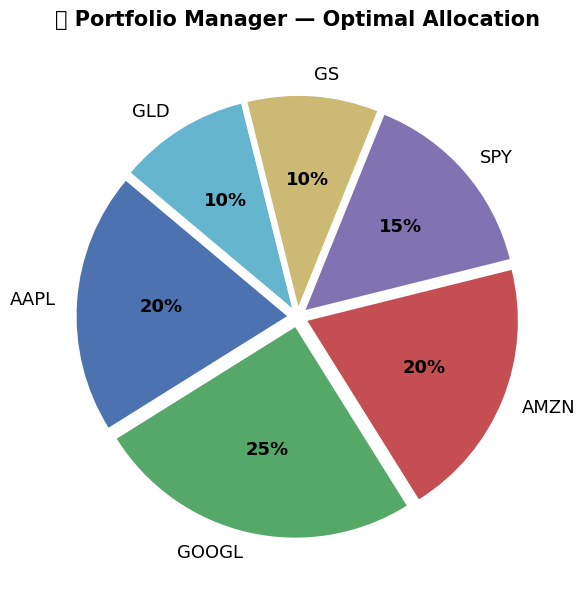

✅ Graphique sauvegardé : portfolio_allocation.png


In [29]:
import matplotlib.pyplot as plt
import json

# Allocation du Portfolio Manager
allocation = {"AAPL": 20, "GOOGL": 25, "AMZN": 20, "SPY": 15, "GS": 10, "GLD": 10}

labels = list(allocation.keys())
sizes = list(allocation.values())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
explode = [0.05] * len(labels)

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.0f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 13}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')

ax.set_title('🧠 Portfolio Manager — Optimal Allocation', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('portfolio_allocation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : portfolio_allocation.png")


[*********************100%***********************]  6 of 6 completed


📈 Rendement Portfolio : 71.62%
📊 Rendement SPY       : 31.77%
⚡ Sharpe Ratio        : 3.28
📉 Max Drawdown        : -13.18%


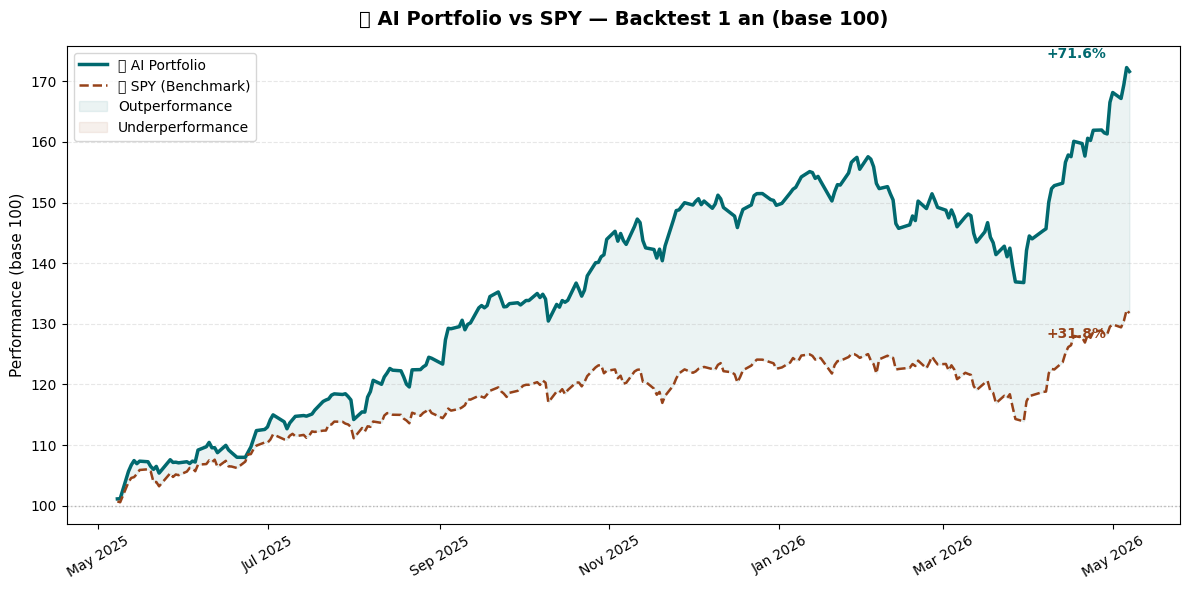

✅ Graphique sauvegardé : backtest_vs_spy.png


In [31]:
import matplotlib.dates as mdates

# Allocation du Portfolio Manager
allocation = {"AAPL": 0.20, "GOOGL": 0.25, "AMZN": 0.20, "SPY": 0.15, "GS": 0.10, "GLD": 0.10}

# Téléchargement des données (1 an)
tickers = list(allocation.keys())
data = yf.download(tickers, period="1y", auto_adjust=True)["Close"]

# Rendements normalisés base 100
returns = data.pct_change().dropna()
portfolio_returns = (returns * pd.Series(allocation)).sum(axis=1)
portfolio_perf = (1 + portfolio_returns).cumprod() * 100
spy_perf = (1 + returns["SPY"]).cumprod() * 100

# ---- Métriques ----
total_return_portfolio = portfolio_perf.iloc[-1] - 100
total_return_spy = spy_perf.iloc[-1] - 100
sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * (252 ** 0.5)
max_dd = ((portfolio_perf / portfolio_perf.cummax()) - 1).min() * 100

print(f"📈 Rendement Portfolio : {total_return_portfolio:.2f}%")
print(f"📊 Rendement SPY       : {total_return_spy:.2f}%")
print(f"⚡ Sharpe Ratio        : {sharpe:.2f}")
print(f"📉 Max Drawdown        : {max_dd:.2f}%")

# ---- Graphique ----
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(portfolio_perf.index, portfolio_perf, label="🧠 AI Portfolio", color="#01696f", linewidth=2.5)
ax.plot(spy_perf.index, spy_perf, label="📊 SPY (Benchmark)", color="#964219", linewidth=1.8, linestyle="--")

ax.fill_between(portfolio_perf.index, portfolio_perf, spy_perf,
                where=(portfolio_perf >= spy_perf), alpha=0.08, color="#01696f", label="Outperformance")
ax.fill_between(portfolio_perf.index, portfolio_perf, spy_perf,
                where=(portfolio_perf < spy_perf), alpha=0.08, color="#964219", label="Underperformance")

ax.axhline(100, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.set_title("🧠 AI Portfolio vs SPY — Backtest 1 an (base 100)", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Performance (base 100)", fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")

final_date = portfolio_perf.index[-1]
ax.annotate(f"+{total_return_portfolio:.1f}%", xy=(final_date, portfolio_perf.iloc[-1]),
            fontsize=10, color="#01696f", fontweight="bold",
            xytext=(-60, 10), textcoords="offset points")
ax.annotate(f"+{total_return_spy:.1f}%", xy=(final_date, spy_perf.iloc[-1]),
            fontsize=10, color="#964219", fontweight="bold",
            xytext=(-60, -18), textcoords="offset points")

plt.tight_layout()
plt.savefig("backtest_vs_spy.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : backtest_vs_spy.png")
